In [1]:
import os
import pandas as pd
import numpy as np
import random
from scipy.stats import truncnorm

In [43]:
this_dir = os.getcwd()
work_dir = os.path.dirname(this_dir)
write_dir = "/mnt/storage/ldl_linguistics/PhonGen2025_diag_new/data_LV/"
# Shuhao used to write this as adaptive path retrieval, but I have to use hardcode the path for now since we are generating on Lab computer but running on Faculty server. --- IGNORE ---

In [44]:
random.seed(42)
noi_vals = [random.randint(10, 90) for _ in range(13)]
print(noi_vals)

[24, 13, 45, 41, 38, 27, 23, 79, 21, 85, 64, 14, 13]


In [45]:
CONSONANT_CONFIGURED_VARIANCE = 15
VOWEL_CONFIGURED_VARIANCE = 15

con_all_means = [50]*2 + noi_vals[0:5] + [50] + [0]*9
con_all_sds = [CONSONANT_CONFIGURED_VARIANCE]*7 + [0]*10
vow_all_means = [0]*7 + [100]*2 + noi_vals[5:13]
vow_all_sds = [0]*9 + [VOWEL_CONFIGURED_VARIANCE]*8

all_means = vow_all_means + con_all_means + vow_all_means
all_sds = vow_all_sds + con_all_sds + vow_all_sds

print(all_means)
print(all_sds)

[0, 0, 0, 0, 0, 0, 0, 100, 100, 27, 23, 79, 21, 85, 64, 14, 13, 50, 50, 24, 13, 45, 41, 38, 50, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 100, 100, 27, 23, 79, 21, 85, 64, 14, 13]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 15, 15, 15, 15, 15, 15, 15, 15]


In [46]:
condition = "test_equal"
data_dir = os.path.join(work_dir, f'data_{condition}')
os.makedirs(data_dir, exist_ok=True)

np.random.seed(42)

consonant_list = ['ts', 'tc', 's', 'c']
consonant_cog = [30, 70, 30, 70]
consonant_fd = [30, 30, 70, 70]
train_refs = [1, 2, 4, 3]

# no. of tokens for each word
sample_size = 8000

metadata = []

for index in range (4):
    consonant = consonant_list[index]
    cog = consonant_cog[index]
    fri_dur = consonant_fd[index]
    train_ref = train_refs[index]

    vowel = 'a'
    f_vals = noi_vals[10:13]

    word = vowel + consonant + vowel

    c_f_means = np.array([cog, fri_dur])

    con_means = np.array(noi_vals[0:5]) # sta_dev, skewness, kurtosis, bur_int, fri_int

    con_means = np.concatenate((c_f_means, con_means))
    con_stds = np.full(shape=con_means.shape, fill_value=CONSONANT_CONFIGURED_VARIANCE)

    consonants = np.zeros((sample_size, len(con_means)))
    for i in range(len(con_means)):
        a, b = - 2*con_stds[i] / con_stds[i], 2*con_stds[i] / con_stds[i]
        dist = truncnorm(a, b, loc = con_means[i], scale = con_stds[i])
        consonants[:, i] = dist.rvs(size = sample_size)
    
    # total duration of fixed value 50 for consonants
    con_dur = np.full((sample_size, 1), 50)

    # zero values for all other features
    zeros = np.full((sample_size, 9), 0)

    # all concatenated
    consonants = np.hstack((consonants, con_dur, zeros))

    vow_means = np.array(noi_vals[5:10]) # voc_int, f0, b3, b2, b1
    vow_means = np.append(vow_means, f_vals) # *, f3, f2, f1
    vow_stds = np.full(shape=vow_means.shape, fill_value=VOWEL_CONFIGURED_VARIANCE)

    vowels = np.zeros((sample_size, len(vow_means)))
    for i in range(len(vow_means)):
        a, b = - 2*vow_stds[i] / vow_stds[i], 2*vow_stds[i] / vow_stds[i]
        dist = truncnorm(a, b, loc = vow_means[i], scale = vow_stds[i])
        vowels[:, i] = dist.rvs(size = sample_size)

    # vocalic duration and total duration of fixed value 100 for vowels
    vow_dur = np.full((sample_size, 2), 100)

    # zero values for all other features
    zeros = np.full((sample_size, 7), 0)

    # all concatenated
    vowels = np.hstack((zeros, vow_dur, vowels))

    subdata_dir = os.path.join(data_dir, word)
    os.makedirs(subdata_dir, exist_ok=True)

    for i in range(sample_size):
        uid = word + f'_{i+1:04d}'
        filename = f'{uid}.npy'
        save_path = os.path.join(subdata_dir, filename)
        
        vcv = np.vstack([vowels[i], consonants[i], vowels[i]])
        np.save(save_path, vcv)

        # save_path_rel = os.path.relpath(save_path, start=work_dir)
        save_path_rel = os.path.join(write_dir, f'data_{condition}', word, filename)
        metadata.append({
            'uid': uid,
            'path': save_path_rel,
            'cog': vcv[1][0],
            'fri_dur': vcv[1][1],
            # 'voicing': vcv[1][8],
            'word': word,
            'consonant': consonant,
            'vowel': vowel,
            'train': train_ref
        })

csv_name = f'metadata_{condition}.csv'
csv_path = os.path.join(data_dir, csv_name)
metaframe = pd.DataFrame(metadata)
metaframe.to_csv(csv_path, index=False)


In [47]:
condition = "train_equal"
data_dir = os.path.join(work_dir, f'data_{condition}')
os.makedirs(data_dir, exist_ok=True)

np.random.seed(42)

consonant_list = ['ts', 'c']
consonant_cog = [30, 70]
consonant_fd = [30, 70]
train_refs = [1, 3]

# no. of tokens for each word
sample_size = 8000

metadata = []

for index in range (2):
    consonant = consonant_list[index]
    cog = consonant_cog[index]
    fri_dur = consonant_fd[index]
    train_ref = train_refs[index]

    vowel = 'a'
    f_vals = noi_vals[10:13]

    word = vowel + consonant + vowel

    c_f_means = np.array([cog, fri_dur])

    con_means = np.array(noi_vals[0:5]) # sta_dev, skewness, kurtosis, bur_int, fri_int

    con_means = np.concatenate((c_f_means, con_means))
    con_stds = np.full(shape=con_means.shape, fill_value=CONSONANT_CONFIGURED_VARIANCE)

    consonants = np.zeros((sample_size, len(con_means)))
    for i in range(len(con_means)):
        a, b = - 2*con_stds[i] / con_stds[i], 2*con_stds[i] / con_stds[i]
        dist = truncnorm(a, b, loc = con_means[i], scale = con_stds[i])
        consonants[:, i] = dist.rvs(size = sample_size)
    
    # total duration of fixed value 50 for consonants
    con_dur = np.full((sample_size, 1), 50)

    # zero values for all other features
    zeros = np.full((sample_size, 9), 0)

    # all concatenated
    consonants = np.hstack((consonants, con_dur, zeros))

    vow_means = np.array(noi_vals[5:10]) # voc_int, f0, b3, b2, b1
    vow_means = np.append(vow_means, f_vals) # *, f3, f2, f1
    vow_stds = np.full(shape=vow_means.shape, fill_value=VOWEL_CONFIGURED_VARIANCE)

    vowels = np.zeros((sample_size, len(vow_means)))
    for i in range(len(vow_means)):
        a, b = - 2*vow_stds[i] / vow_stds[i], 2*vow_stds[i] / vow_stds[i]
        dist = truncnorm(a, b, loc = vow_means[i], scale = vow_stds[i])
        vowels[:, i] = dist.rvs(size = sample_size)

    # vocalic duration and total duration of fixed value 100 for vowels
    vow_dur = np.full((sample_size, 2), 100)

    # zero values for all other features
    zeros = np.full((sample_size, 7), 0)

    # all concatenated
    vowels = np.hstack((zeros, vow_dur, vowels))

    subdata_dir = os.path.join(data_dir, word)
    os.makedirs(subdata_dir, exist_ok=True)

    for i in range(sample_size):
        uid = word + f'_{i+1:04d}'
        filename = f'{uid}.npy'
        save_path = os.path.join(subdata_dir, filename)
        
        vcv = np.vstack([vowels[i], consonants[i], vowels[i]])
        np.save(save_path, vcv)

        # save_path_rel = os.path.relpath(save_path, start=work_dir)
        save_path_rel = os.path.join(write_dir, f'data_{condition}', word, filename)
        metadata.append({
            'uid': uid,
            'path': save_path_rel,
            'cog': vcv[1][0],
            'fri_dur': vcv[1][1],
            # 'voicing': vcv[1][8],
            'word': word,
            'consonant': consonant,
            'vowel': vowel,
            'train': train_ref
        })

csv_name = f'metadata_{condition}.csv'
csv_path = os.path.join(data_dir, csv_name)
metaframe = pd.DataFrame(metadata)
metaframe.to_csv(csv_path, index=False)


In [48]:
condition = "test_unequal"
data_dir = os.path.join(work_dir, f'data_{condition}')
os.makedirs(data_dir, exist_ok=True)

np.random.seed(42)

consonant_list = ['ts', 'tc', 's', 'c']
consonant_cog = [10, 90, 10, 90]
consonant_fd = [30, 30, 70, 70]
train_refs = [1, 2, 4, 3]

# no. of tokens for each word
sample_size = 8000

metadata = []

for index in range (4):
    consonant = consonant_list[index]
    cog = consonant_cog[index]
    fri_dur = consonant_fd[index]
    train_ref = train_refs[index]

    vowel = 'a'
    f_vals = noi_vals[10:13]

    word = vowel + consonant + vowel

    c_f_means = np.array([cog, fri_dur])

    con_means = np.array(noi_vals[0:5]) # sta_dev, skewness, kurtosis, bur_int, fri_int

    con_means = np.concatenate((c_f_means, con_means))
    con_stds = np.full(shape=con_means.shape, fill_value=CONSONANT_CONFIGURED_VARIANCE)

    consonants = np.zeros((sample_size, len(con_means)))
    for i in range(len(con_means)):
        a, b = - 2*con_stds[i] / con_stds[i], 2*con_stds[i] / con_stds[i]
        dist = truncnorm(a, b, loc = con_means[i], scale = con_stds[i])
        consonants[:, i] = dist.rvs(size = sample_size)
    
    # total duration of fixed value 50 for consonants
    con_dur = np.full((sample_size, 1), 50)

    # zero values for all other features
    zeros = np.full((sample_size, 9), 0)

    # all concatenated
    consonants = np.hstack((consonants, con_dur, zeros))

    vow_means = np.array(noi_vals[5:10]) # voc_int, f0, b3, b2, b1
    vow_means = np.append(vow_means, f_vals) # *, f3, f2, f1
    vow_stds = np.full(shape=vow_means.shape, fill_value=VOWEL_CONFIGURED_VARIANCE)

    vowels = np.zeros((sample_size, len(vow_means)))
    for i in range(len(vow_means)):
        a, b = - 2*vow_stds[i] / vow_stds[i], 2*vow_stds[i] / vow_stds[i]
        dist = truncnorm(a, b, loc = vow_means[i], scale = vow_stds[i])
        vowels[:, i] = dist.rvs(size = sample_size)

    # vocalic duration and total duration of fixed value 100 for vowels
    vow_dur = np.full((sample_size, 2), 100)

    # zero values for all other features
    zeros = np.full((sample_size, 7), 0)

    # all concatenated
    vowels = np.hstack((zeros, vow_dur, vowels))

    subdata_dir = os.path.join(data_dir, word)
    os.makedirs(subdata_dir, exist_ok=True)

    for i in range(sample_size):
        uid = word + f'_{i+1:04d}'
        filename = f'{uid}.npy'
        save_path = os.path.join(subdata_dir, filename)
        
        vcv = np.vstack([vowels[i], consonants[i], vowels[i]])
        np.save(save_path, vcv)

        # save_path_rel = os.path.relpath(save_path, start=work_dir)
        save_path_rel = os.path.join(write_dir, f'data_{condition}', word, filename)
        metadata.append({
            'uid': uid,
            'path': save_path_rel,
            'cog': vcv[1][0],
            'fri_dur': vcv[1][1],
            # 'voicing': vcv[1][8],
            'word': word,
            'consonant': consonant,
            'vowel': vowel,
            'train': train_ref
        })

csv_name = f'metadata_{condition}.csv'
csv_path = os.path.join(data_dir, csv_name)
metaframe = pd.DataFrame(metadata)
metaframe.to_csv(csv_path, index=False)


In [49]:
condition = "train_unequal"
data_dir = os.path.join(work_dir, f'data_{condition}')
os.makedirs(data_dir, exist_ok=True)

np.random.seed(42)

consonant_list = ['ts', 'c']
consonant_cog = [10, 90]
consonant_fd = [30, 70]
train_refs = [1, 3]

# no. of tokens for each word
sample_size = 8000

metadata = []

for index in range (2):
    consonant = consonant_list[index]
    cog = consonant_cog[index]
    fri_dur = consonant_fd[index]
    train_ref = train_refs[index]

    vowel = 'a'
    f_vals = noi_vals[10:13]

    word = vowel + consonant + vowel

    c_f_means = np.array([cog, fri_dur])

    con_means = np.array(noi_vals[0:5]) # sta_dev, skewness, kurtosis, bur_int, fri_int

    con_means = np.concatenate((c_f_means, con_means))
    con_stds = np.full(shape=con_means.shape, fill_value=CONSONANT_CONFIGURED_VARIANCE)

    consonants = np.zeros((sample_size, len(con_means)))
    for i in range(len(con_means)):
        a, b = - 2*con_stds[i] / con_stds[i], 2*con_stds[i] / con_stds[i]
        dist = truncnorm(a, b, loc = con_means[i], scale = con_stds[i])
        consonants[:, i] = dist.rvs(size = sample_size)
    
    # total duration of fixed value 50 for consonants
    con_dur = np.full((sample_size, 1), 50)

    # zero values for all other features
    zeros = np.full((sample_size, 9), 0)

    # all concatenated
    consonants = np.hstack((consonants, con_dur, zeros))

    vow_means = np.array(noi_vals[5:10]) # voc_int, f0, b3, b2, b1
    vow_means = np.append(vow_means, f_vals) # *, f3, f2, f1
    vow_stds = np.full(shape=vow_means.shape, fill_value=VOWEL_CONFIGURED_VARIANCE)

    vowels = np.zeros((sample_size, len(vow_means)))
    for i in range(len(vow_means)):
        a, b = - 2*vow_stds[i] / vow_stds[i], 2*vow_stds[i] / vow_stds[i]
        dist = truncnorm(a, b, loc = vow_means[i], scale = vow_stds[i])
        vowels[:, i] = dist.rvs(size = sample_size)

    # vocalic duration and total duration of fixed value 100 for vowels
    vow_dur = np.full((sample_size, 2), 100)

    # zero values for all other features
    zeros = np.full((sample_size, 7), 0)

    # all concatenated
    vowels = np.hstack((zeros, vow_dur, vowels))

    subdata_dir = os.path.join(data_dir, word)
    os.makedirs(subdata_dir, exist_ok=True)

    for i in range(sample_size):
        uid = word + f'_{i+1:04d}'
        filename = f'{uid}.npy'
        save_path = os.path.join(subdata_dir, filename)
        
        vcv = np.vstack([vowels[i], consonants[i], vowels[i]])
        np.save(save_path, vcv)

        # save_path_rel = os.path.relpath(save_path, start=work_dir)
        save_path_rel = os.path.join(write_dir, f'data_{condition}', word, filename)
        metadata.append({
            'uid': uid,
            'path': save_path_rel,
            'cog': vcv[1][0],
            'fri_dur': vcv[1][1],
            # 'voicing': vcv[1][8],
            'word': word,
            'consonant': consonant,
            'vowel': vowel,
            'train': train_ref
        })

csv_name = f'metadata_{condition}.csv'
csv_path = os.path.join(data_dir, csv_name)
metaframe = pd.DataFrame(metadata)
metaframe.to_csv(csv_path, index=False)


In [50]:
# x = '/mnt/ldl_linguistics/PhonGen2025_diag_new/data/data_test_equal/atsa/atsa_0001.npy'

# # insert after /mnt/ "storage/"
# x.replace('/mnt/', '/mnt/storage/')

## Visualize dataset

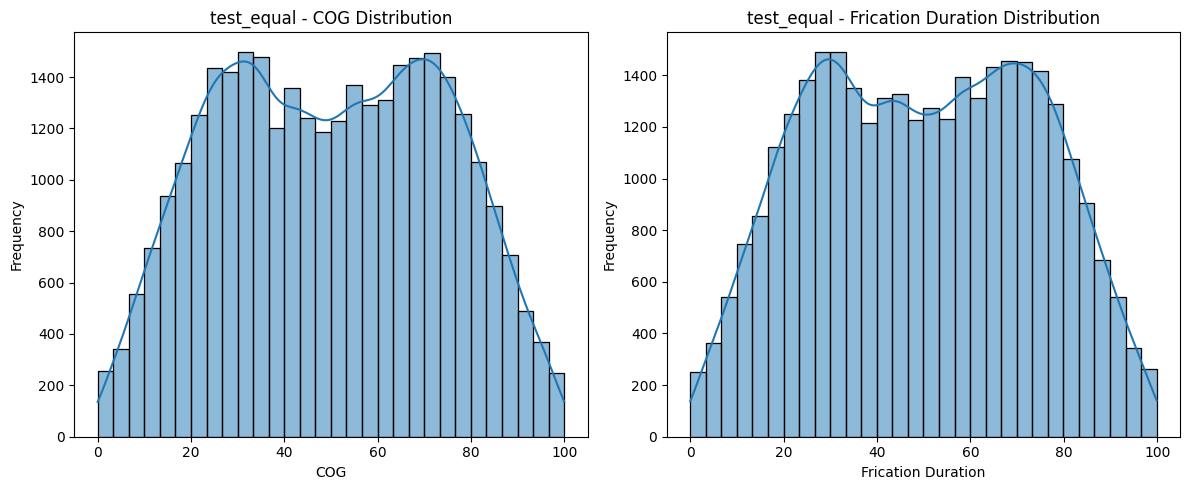

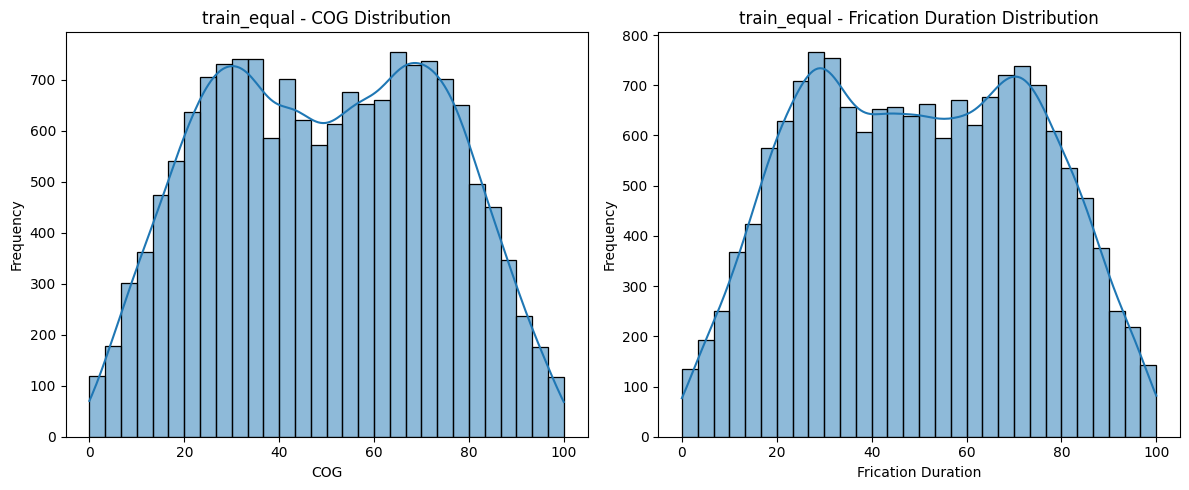

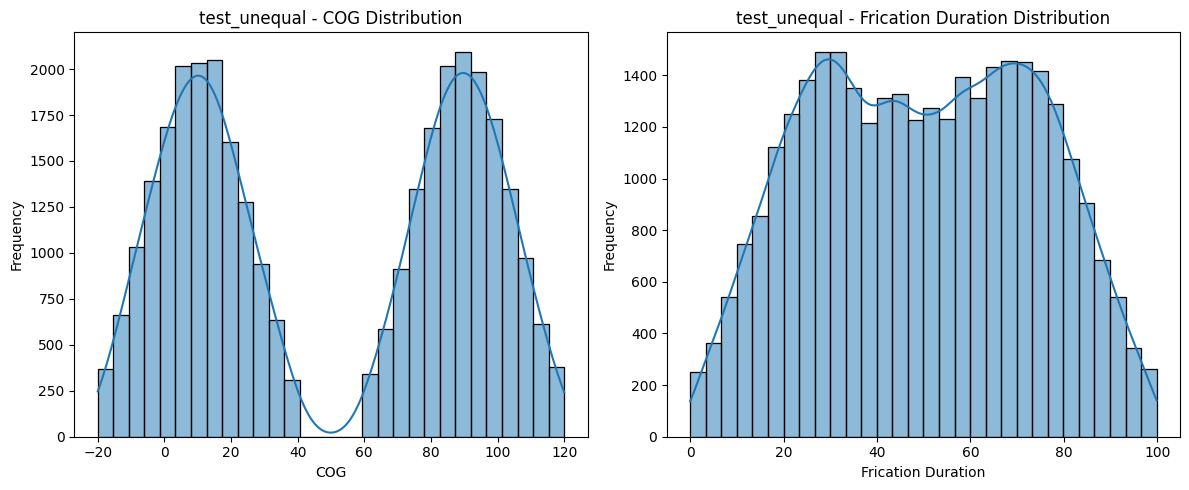

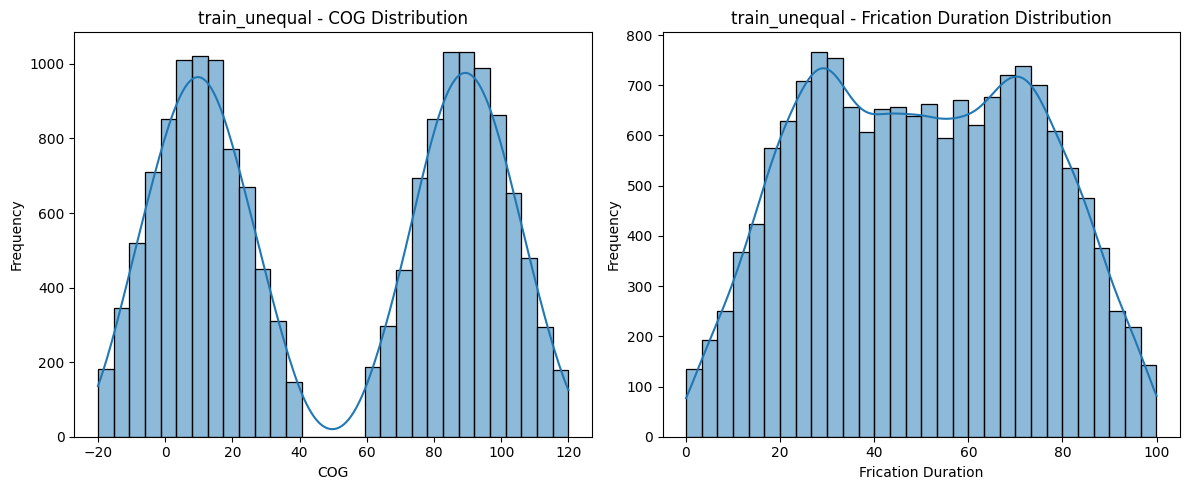

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

CONDITION_LIST = ["test_equal", "train_equal", "test_unequal", "train_unequal"]
ROOT_DIR = "./../"

for condition in CONDITION_LIST: 
    meta_path = os.path.join(ROOT_DIR, f'data_{condition}', f'metadata_{condition}.csv')
    metaframe = pd.read_csv(meta_path)

    # plot the distribution of cog and fri_dur for each condition
    # imported related libraries
    # plot the distribution of cog and fri_dur for each condition
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(metaframe['cog'], bins=30, kde=True)
    plt.title(f'{condition} - COG Distribution')
    plt.xlabel('COG')
    plt.ylabel('Frequency')
    plt.subplot(1, 2, 2)
    sns.histplot(metaframe['fri_dur'], bins=30, kde=True)
    plt.title(f'{condition} - Frication Duration Distribution')
    plt.xlabel('Frication Duration')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# Some Quick Notes

Becuase I am generating data here. I leave some notes here for future refernce: 
1. When generating data, just run through it. Changing vairance is done by changing `CONSONANT_/VOWEL_CONFIGURED_VARIANCE`. Changing mean is done in each condition separately. 
2. After generating the data, they will appear in the hyperdir of this dir. Need to put them all into a dir for transfering. 
3. Use `scp -r /mnt/data/Projects/XXX franklhtan@10.64.109.137:/nfs/ldl_linguistics/PhonGen2025_diag_new/` to transfer. XXX is the data collection name. This should be the same as configured in `write_dir = "/mnt/storage/ldl_linguistics/PhonGen2025_diag_new/XXX/"`. 